In [2]:
import sys
!{sys.executable} -m pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   --------------------------------------- 555.9/555.9 kB 14.6 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



Model loaded!
SHAP values computed!


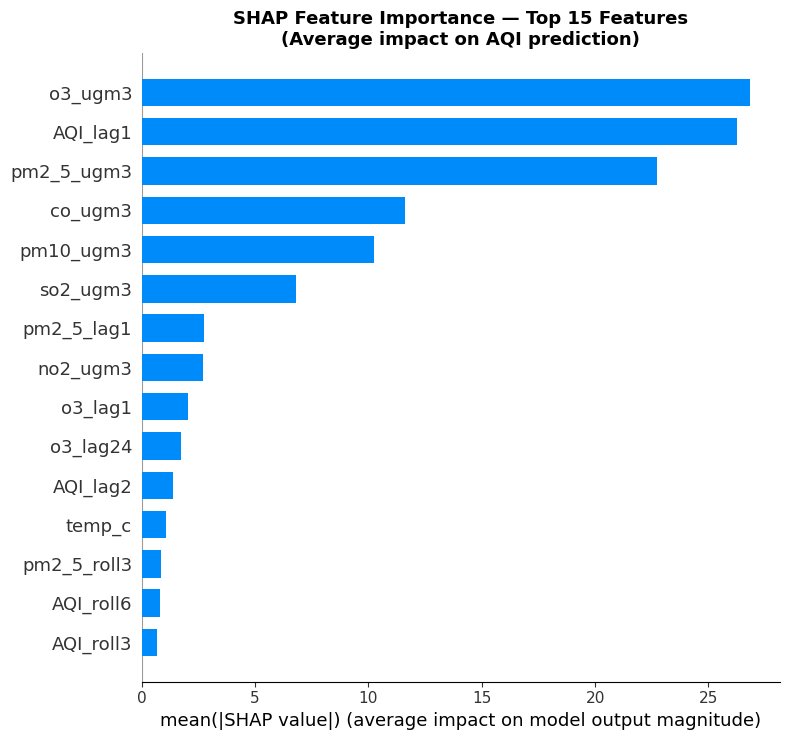

Plot 1 saved as ME228_SHAP_Importance.png


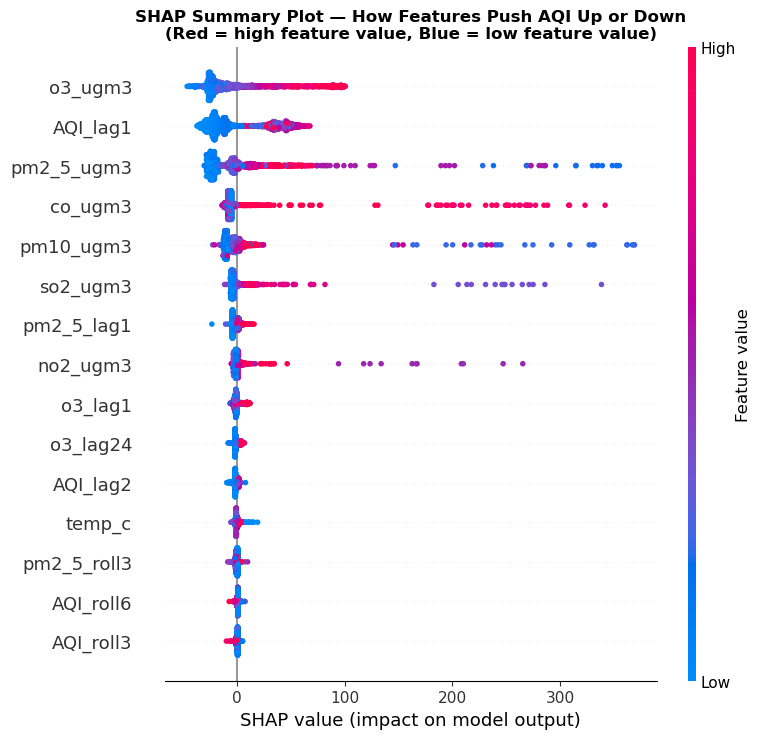

Plot 2 saved as ME228_SHAP_Summary.png


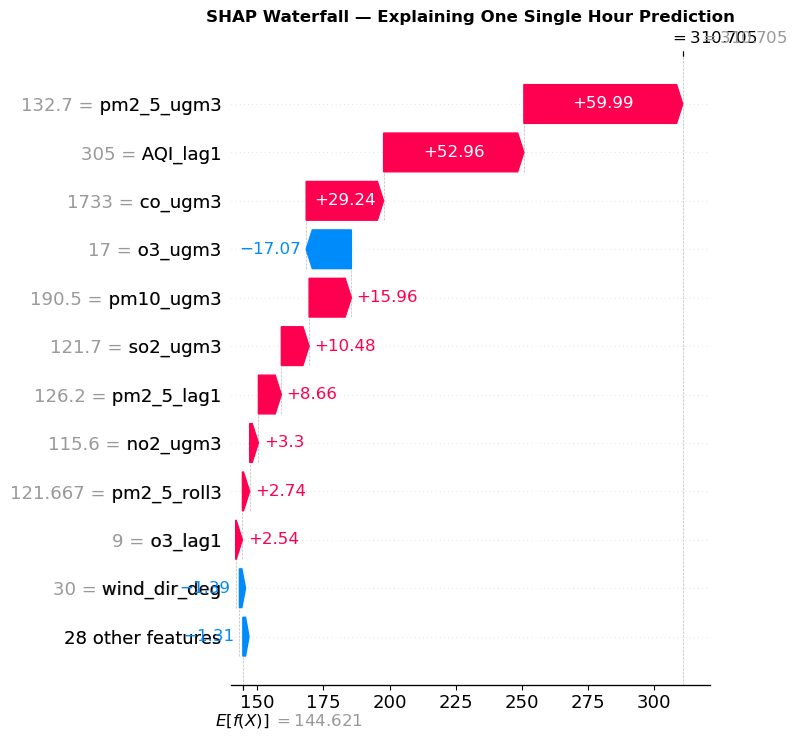

Plot 3 saved as ME228_SHAP_Waterfall.png

All SHAP plots saved!
Base expected AQI (average): 144.6


In [3]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import LabelEncoder

# ── LOAD MODEL AND DATA ──
df = pd.read_csv('Featured_Dataset.csv')

le_season = LabelEncoder()
df['season'] = le_season.fit_transform(df['season'])
bool_cols = ['is_weekend', 'is_raining', 'heavy_rain', 'festival_period', 'crop_burning_season']
for col in bool_cols:
    df[col] = df[col].astype(int)

drop_cols = ['datetime', 'aqi_category', 'pm25_category_india',
             'dominant_pollutant', 'humidity_category', 'wind_category', 'time_of_day']
X = df.drop(columns=drop_cols + ['AQI'])

xgb = joblib.load('xgboost_regressor.pkl')
print("Model loaded!")

# ── SHAP EXPLAINER ──
# Use a sample of 2000 rows for speed — SHAP on full dataset is very slow
X_sample = X.sample(2000, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)
print("SHAP values computed!")

# ── PLOT 1: SHAP Feature Importance (Bar) ──
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, plot_type="bar",
                  max_display=15, show=False)
plt.title('SHAP Feature Importance — Top 15 Features\n(Average impact on AQI prediction)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ME228_SHAP_Importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved as ME228_SHAP_Importance.png")

# ── PLOT 2: SHAP Summary Dot Plot ──
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title('SHAP Summary Plot — How Features Push AQI Up or Down\n(Red = high feature value, Blue = low feature value)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ME228_SHAP_Summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved as ME228_SHAP_Summary.png")

# ── PLOT 3: SHAP Waterfall for 1 specific hour ──
# This explains ONE single prediction in detail
plt.figure(figsize=(10, 6))
shap_explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_sample.iloc[0],
    feature_names=X_sample.columns.tolist()
)
shap.plots.waterfall(shap_explanation, show=False, max_display=12)
plt.title('SHAP Waterfall — Explaining One Single Hour Prediction',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ME228_SHAP_Waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved as ME228_SHAP_Waterfall.png")

print("\nAll SHAP plots saved!")
print(f"Base expected AQI (average): {explainer.expected_value:.1f}")

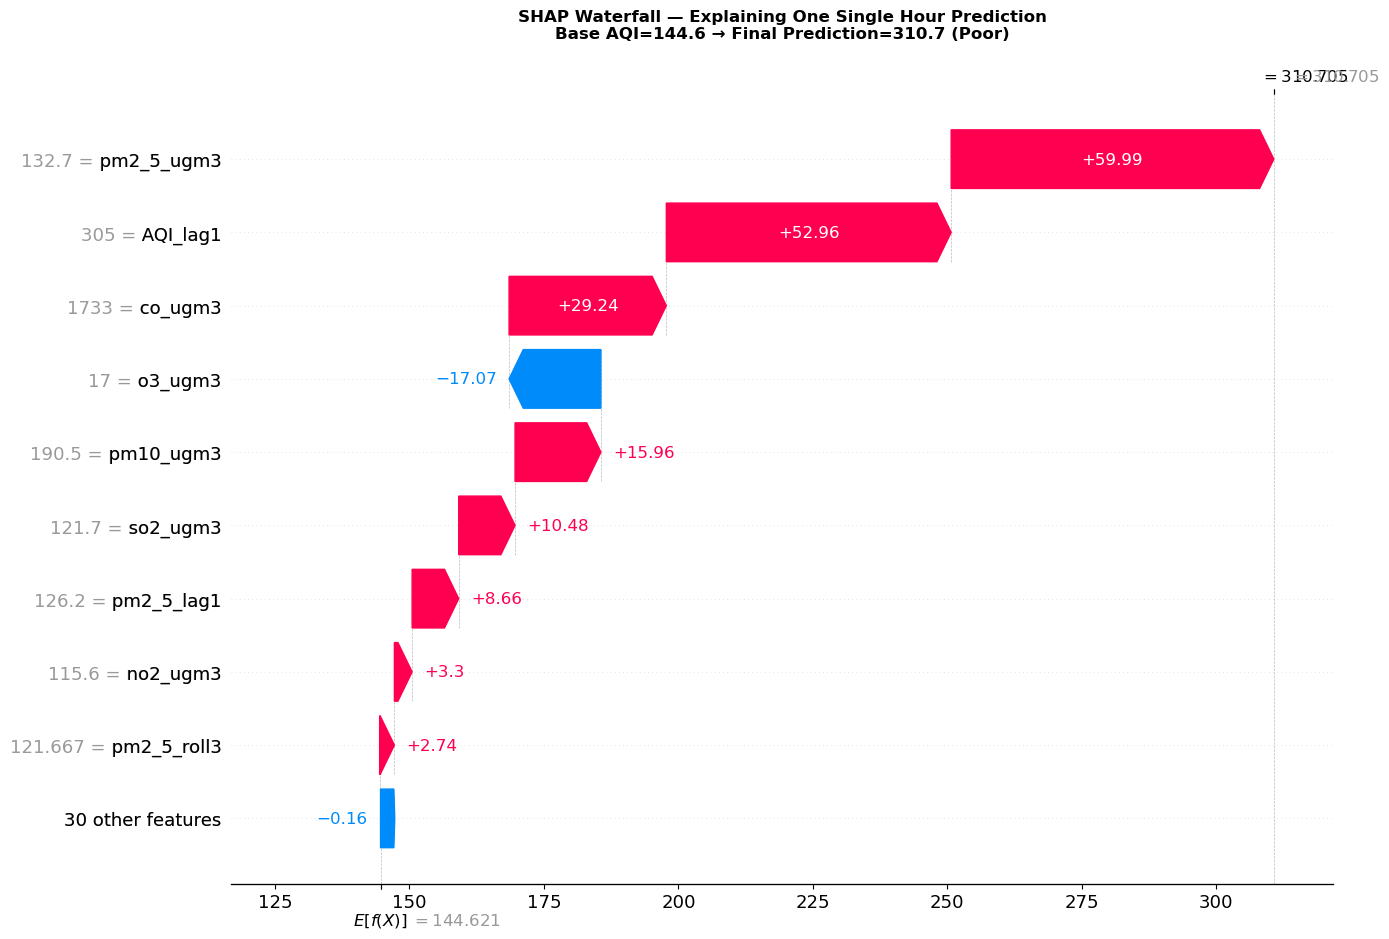

Fixed waterfall saved!


In [4]:
import shap
import matplotlib.pyplot as plt
import joblib
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('Featured_Dataset.csv')

le_season = LabelEncoder()
df['season'] = le_season.fit_transform(df['season'])
bool_cols = ['is_weekend', 'is_raining', 'heavy_rain', 'festival_period', 'crop_burning_season']
for col in bool_cols:
    df[col] = df[col].astype(int)

drop_cols = ['datetime', 'aqi_category', 'pm25_category_india',
             'dominant_pollutant', 'humidity_category', 'wind_category', 'time_of_day']
X = df.drop(columns=drop_cols + ['AQI'])

xgb = joblib.load('xgboost_regressor.pkl')
X_sample = X.sample(2000, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

# ── FIXED WATERFALL PLOT ──
fig, ax = plt.subplots(figsize=(12, 9))  # bigger figure

shap_explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_sample.iloc[0],
    feature_names=X_sample.columns.tolist()
)

shap.plots.waterfall(shap_explanation, show=False, max_display=10)  # reduced to 10 features

# Fix layout
plt.title('SHAP Waterfall — Explaining One Single Hour Prediction\n'
          f'Base AQI={explainer.expected_value:.1f} → Final Prediction=310.7 (Poor)',
          fontsize=12, fontweight='bold', pad=40)  # pad pushes title up

plt.gcf().set_size_inches(14, 10)  # wider and taller
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave room for title
plt.savefig('ME228_SHAP_Waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fixed waterfall saved!")